### Step 6 – 2k 影像的滑動視窗推論與可視化

In [32]:
from pathlib import Path
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from skimage import io, filters, morphology, exposure, color
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torch.cuda.amp import autocast
import numpy as np
from scipy import ndimage

In [33]:
MODEL_DIR = Path("process/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
TEST_IMAGE = Path("process/tile/tile_x153600_y59392.tiff")
OUTPUT_DIR = Path("process/test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "unet1.pth"

/tmp/ipykernel_199229/216807087.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


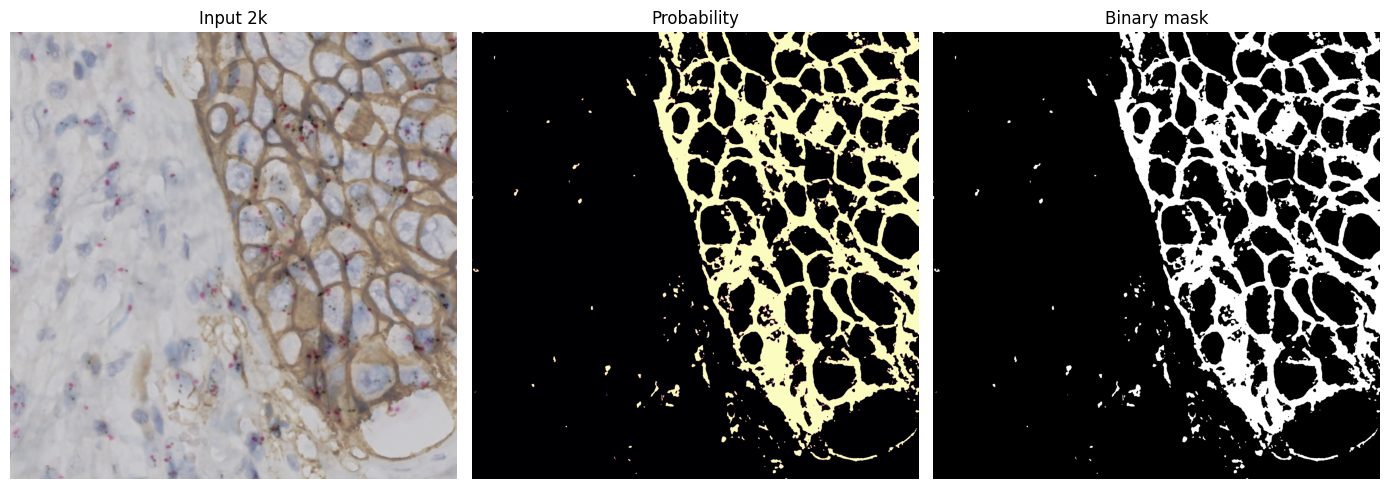

In [34]:
# 2k inference (robust if kernel was restarted)
# Ensure device & model dir
if "device" not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_path = MODEL_DIR / "unet1.pt"
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

# Recreate model if missing
if "model" not in globals():
    model = smp.Unet(
        encoder_name='efficientnet-b0',
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    ).to(device)

# Load checkpoint
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state["model_state"])
model.eval()

# Simple full-image preprocessing (no crop) for 2k TIFF
inference_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def preprocess_image(path: Path):
    img = np.array(Image.open(path).convert("RGB"))
    augmented = inference_transform(image=img)
    tensor = augmented["image"]  # CHW float
    return img, tensor

def run_inference(image_path: Path, model: torch.nn.Module, device: torch.device, threshold: float = 0.5):
    img_np, img_t = preprocess_image(image_path)
    with torch.no_grad(), autocast():
        logits = model(img_t.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    mask_bin = (prob > threshold).astype(np.uint8) * 255
    return img_np, prob, mask_bin

# Paths

# Run inference
raw_img, prob_map, mask_bin = run_inference(TEST_IMAGE, model, device, threshold=0.5)

# Save outputs
Image.fromarray(mask_bin).save(OUTPUT_DIR / "mask_binary.png")
np.save(OUTPUT_DIR / "prob.npy", prob_map)
plt.imsave(OUTPUT_DIR / "prob_vis.png", prob_map, cmap="magma")

# Quick visualization
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1); plt.imshow(raw_img); plt.title("Input 2k"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(prob_map, cmap="magma"); plt.title("Probability"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(mask_bin, cmap="gray"); plt.title("Binary mask"); plt.axis("off")
plt.tight_layout()
plt.show()

正在執行拓撲運算 (這可能需要幾秒鐘)...


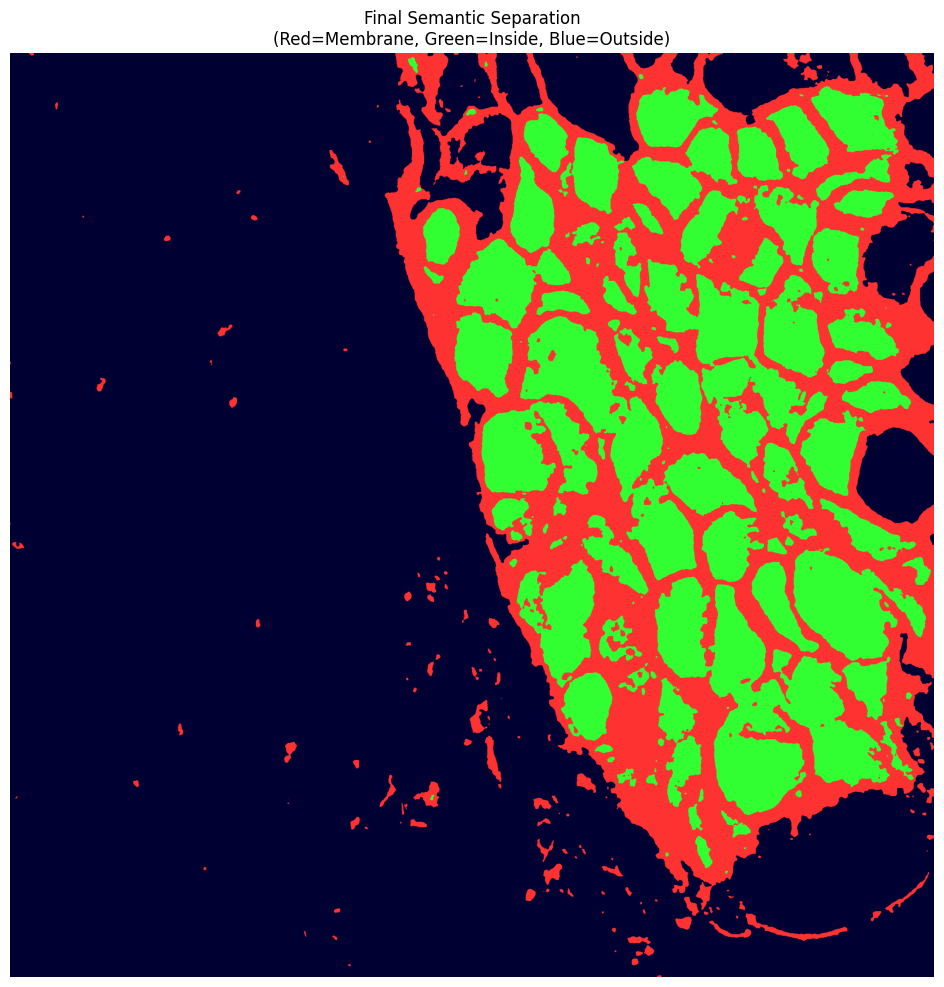

In [35]:
def visualize_final_separation_2k(mask_bin_path):
    # 1. 讀取你剛剛生成的 Binary Mask
    # 確保是 0 或 1 的二值化圖片
    mask_ring = np.array(Image.open(mask_bin_path))
    mask_ring = (mask_ring > 128).astype(np.uint8) # 確保是 0/1

    print("正在執行拓撲運算 (這可能需要幾秒鐘)...")
    
    # 2. 關鍵步驟：孔洞填充 (Binary Fill Holes)
    # 這步會把所有 "蜂巢內的洞" 填起來，變成實心
    mask_filled = ndimage.binary_fill_holes(mask_ring).astype(np.uint8)
    
    # 3. 集合運算分離三區
    # A. 內部區域 (Inside) = 實心圓 - 環
    mask_inside = cv2.subtract(mask_filled, mask_ring)
    
    # B. 外部區域 (Outside) = 全白 - 實心圓
    mask_outside = 1 - mask_filled

    # 4. 視覺化合成 (用彩色顯示比較清楚)
    # 建立一個 RGB 畫布
    h, w = mask_ring.shape
    vis_img = np.zeros((h, w, 3), dtype=np.uint8)
    
    # 定義顏色
    # 紅色表示牆壁 (Membrane)
    vis_img[mask_ring == 1] = [255, 50, 50]   
    # 綠色表示內部 (Nuclei/Cytoplasm)
    vis_img[mask_inside == 1] = [50, 255, 50] 
    # 藍色表示外部 (Background/Stroma)
    vis_img[mask_outside == 1] = [0, 0, 50]   

    # 5. 畫圖
    plt.figure(figsize=(12, 12))
    plt.title("Final Semantic Separation\n(Red=Membrane, Green=Inside, Blue=Outside)")
    plt.imshow(vis_img)
    plt.axis('off')
    plt.show()

    return mask_inside, mask_outside

# === 執行 ===
# 指向你剛剛存的 mask_binary.png
MASK_PATH = OUTPUT_DIR / "mask_binary.png"
mask_in, mask_out = visualize_final_separation_2k(MASK_PATH)

### Unet分割影像

In [36]:
# ================= 1. 參數設定區 (可微調) =================
# 路徑設定
MODEL_PATH = "process/models/unet3.pt"     # 你的模型路徑
IMAGE_PATH = "process/tile/tile_x155648_y47104.tiff" # 你要測試的圖片路徑
OUTPUT_DIR = Path("process/test")# 只輸出最終成品的資料夾
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 閾值設定
MASK_THRESHOLD = 0.5        # U-Net 機率閾值
MIN_WALL_SIZE = 500         # 清洗牆壁用：小於這個面積的白色區塊會被擦掉 (視為誤判的紅點)
DOT_MIN_AREA = 5            # 點偵測用：太小的點當雜訊
DOT_MAX_AREA = 250          # 點偵測用：太大的點當細胞核或邊緣，忽略

In [37]:
# ================= 2. 模型載入與初始化 =================
def load_model(path, device):
    print(f"🚀 正在載入模型: {path}...")
    model = smp.Unet(
        encoder_name='efficientnet-b0',
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    ).to(device)
    
    # 載入權重
    checkpoint = torch.load(path, map_location=device)
    # 檢查是否包含 "model_state" key，若沒有則直接載入
    if "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model

In [38]:
# ================= 3. 核心功能函式庫 =================

def preprocess_image(image_path):
    """讀取並預處理圖片"""
    img_pil = Image.open(image_path).convert("RGB")
    img_np = np.array(img_pil)
    
    transform = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    
    augmented = transform(image=img_np)
    return img_np, augmented["image"]

def clean_unet_mask(pred_mask, min_size):
    """
    [關鍵步驟] 清洗 U-Net 輸出
    把誤判為牆壁的紅點(小白點)擦掉，變回黑色背景，這樣稍後才能被算進內部區域。
    """
    mask_bool = pred_mask > 0
    # 移除小物件 (Connectivity=2 代表 8-連通)
    cleaned_bool = morphology.remove_small_objects(mask_bool, min_size=min_size, connectivity=2)
    return cleaned_bool.astype(np.uint8)

🚀 正在載入模型: process/models/unet3.pt...
🧠 正在進行 U-Net 分割...
🧹 正在清洗遮罩 (移除小於 500 像素的雜訊)...
🧩 正在進行拓撲運算 (分離內外)...
🎨 正在繪製結果...


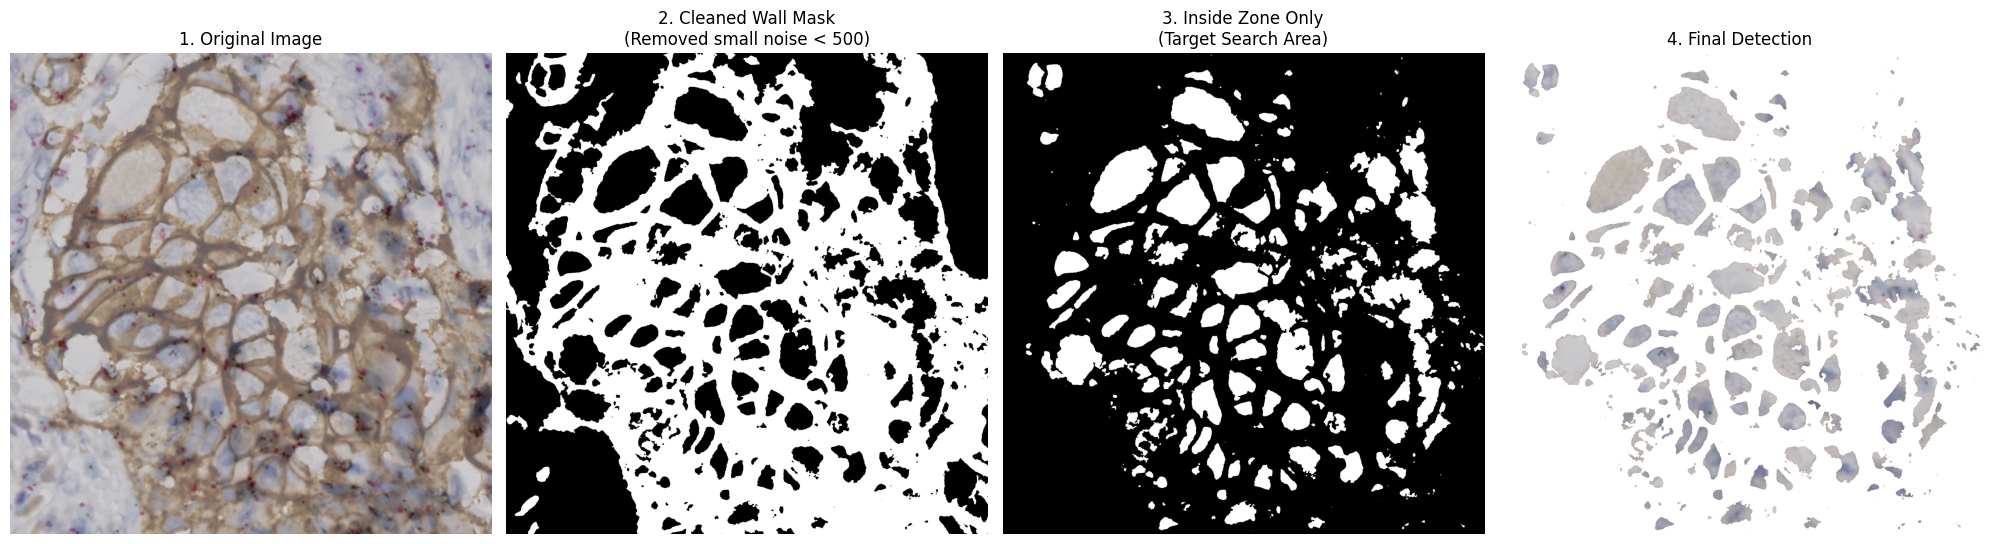

✅ 最終影像已儲存: process/test/final_detection.png


In [39]:
def detect_dots_in_inside_zone(raw_img, inside_mask):
    """
    在 '內部區域' 尋找原圖的紅黑點
    """
    # 轉 HSV
    hsv = cv2.cvtColor(raw_img, cv2.COLOR_RGB2HSV)
    
    # --- 定義紅點 (Red) ---
    # 範圍1 (跨越 0 度)
    lower_red1 = np.array([0, 40, 0])
    upper_red1 = np.array([15, 255, 255])
    # 範圍2 (跨越 180 度)
    lower_red2 = np.array([160, 40, 0])
    upper_red2 = np.array([180, 255, 255])
    mask_red = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1), 
                              cv2.inRange(hsv, lower_red2, upper_red2))
    
    # --- 定義黑點 (Black/Dark Blue) ---
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 60]) # Value < 60 代表很黑
    mask_black = cv2.inRange(hsv, lower_black, upper_black)

    # 合併潛在候選點
    mask_candidates = cv2.bitwise_or(mask_red, mask_black)

    # [重點] 只保留 Inside Mask 裡面的點
    mask_valid = cv2.bitwise_and(mask_candidates, mask_candidates, mask=inside_mask)

    # --- 形態學與面積篩選 ---
    # 去除噪點 (開運算)
    kernel = np.ones((2,2), np.uint8)
    mask_clean = cv2.morphologyEx(mask_valid, cv2.MORPH_OPEN, kernel)
    
    # 輪廓篩選
    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    final_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # 濾掉太大(可能是細胞邊緣)或太小(雜訊)的東西
        if DOT_MIN_AREA < area < DOT_MAX_AREA:
            final_contours.append(cnt)
            
    return final_contours

# ================= 4. 主流程 (Pipeline) =================

def run_full_analysis():
    # A. 準備模型與圖片
    model = load_model(MODEL_PATH, DEVICE)
    original_img, img_tensor = preprocess_image(IMAGE_PATH)
    
    # B. U-Net 推論
    print("🧠 正在進行 U-Net 分割...")
    with torch.no_grad():
        # 加上 autocast 確保與訓練時一致 (若是 CUDA)
        with torch.amp.autocast('cuda') if DEVICE=='cuda' else torch.no_grad():
            logits = model(img_tensor.unsqueeze(0).to(DEVICE))
            prob = torch.sigmoid(logits).squeeze().cpu().numpy()
            
    # 初步二值化 (包含雜訊)
    mask_raw = (prob > MASK_THRESHOLD).astype(np.uint8)

    # C. [清洗] 擦掉誤判的紅點
    print(f"🧹 正在清洗遮罩 (移除小於 {MIN_WALL_SIZE} 像素的雜訊)...")
    mask_wall_clean = clean_unet_mask(mask_raw, min_size=MIN_WALL_SIZE)

    # D. [拓撲] 計算內部區域
    print("🧩 正在進行拓撲運算 (分離內外)...")
    # 填滿所有封閉區域 -> 得到 (牆壁 + 內部)
    mask_filled = ndimage.binary_fill_holes(mask_wall_clean).astype(np.uint8)
    
    # 內部區域 = 填滿的 - 只有牆壁的
    mask_inside = cv2.subtract(mask_filled, mask_wall_clean)
    # ================= 5. 結果視覺化 =================
    print("🎨 正在繪製結果...")
    
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))
    
    # 圖 1: 原圖
    ax[0].imshow(original_img)
    ax[0].set_title("1. Original Image")
    ax[0].axis('off')
    
    # 圖 2: 清洗後的牆壁 (注意紅點應該要不見，變黑色)
    ax[1].imshow(mask_wall_clean, cmap='gray')
    ax[1].set_title(f"2. Cleaned Wall Mask\n(Removed small noise < {MIN_WALL_SIZE})")
    ax[1].axis('off')
    
    # 圖 3: 內部區域 (這是我們的搜尋範圍)
    ax[2].imshow(mask_inside, cmap='gray')
    ax[2].set_title("3. Inside Zone Only\n(Target Search Area)")
    ax[2].axis('off')
    
    # 圖 4: 最終結果 (原圖 + 綠色圈圈)
    # 製作一張畫好圈圈的圖
    final_vis = original_img.copy()
    # 把背景塗白 (讓綠色圈圈更明顯)
    mask_outside = 1 - mask_inside
    final_vis[mask_outside == 1] = [255, 255, 255] # 背景變白
    ax[3].imshow(final_vis)
    ax[3].set_title(f"4. Final Detection")
    ax[3].axis('off')
    
    plt.tight_layout()
    plt.show()

    # 只輸出最終成品
    final_path = OUTPUT_DIR / "final_detection.png"
    Image.fromarray(final_vis).save(final_path, quality=95)
    print(f"✅ 最終影像已儲存: {final_path}")

# 執行程式
if __name__ == "__main__":
    run_full_analysis()
